<a href="https://colab.research.google.com/github/irungugraceig-sudo/4d-perception-engine/blob/main/Assignment_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Clone the repo (downloads the data)

In [ ]:
!git clone https://github.com/waico/SKAB.git

fatal: destination path 'SKAB' already exists and is not an empty directory.


Cell 2 — Normal data:

In [ ]:
import pandas as pd

df_normal = pd.read_csv("./SKAB/data/other/1.csv", sep=";",
                         index_col="datetime", parse_dates=True)
print("Shape:", df_normal.shape)
print("Columns:", df_normal.columns.tolist())
print("Anomaly label counts:")
print(df_normal["anomaly"].value_counts())
df_normal.head()

Shape: (745, 10)
Columns: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
Anomaly label counts:
anomaly
0.0    557
1.0    188
Name: count, dtype: int64


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-03-01 15:44:06,0.082065,0.133521,1.27794,0.054711,92.2562,22.2577,209.639,76.0197,0.0,0.0
2020-03-01 15:44:07,0.082724,0.132378,1.12118,-0.273216,92.0144,22.2577,221.250,76.9806,0.0,0.0
2020-03-01 15:44:08,0.081648,0.139038,1.93242,0.054711,92.2413,22.2748,236.615,76.0197,0.0,0.0
2020-03-01 15:44:09,0.083335,0.132742,1.25962,-0.273216,92.2438,22.2657,230.375,77.0000,0.0,0.0
2020-03-01 15:44:10,0.082272,0.133171,1.59773,0.054711,92.3611,22.2591,249.701,77.0000,0.0,0.0


Anomaly label distribution in valve1/1.csv:

In [ ]:
df_anomaly = pd.read_csv("./SKAB/data/valve1/1.csv", sep=";",
                          index_col="datetime", parse_dates=True)
print("Shape:", df_anomaly.shape)
print("Anomaly label counts:")
print(df_anomaly["anomaly"].value_counts())
df_anomaly.head()

Shape: (1145, 10)
Anomaly label counts:
anomaly
0.0    743
1.0    402
Name: count, dtype: int64


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-03-09 10:34:33,0.027080,0.039615,0.871339,0.054711,75.4955,25.8338,244.091,32.0000,0.0,0.0
2020-03-09 10:34:34,0.026995,0.038759,1.301280,0.054711,75.5445,25.8408,224.170,32.0000,0.0,0.0
2020-03-09 10:34:35,0.026807,0.039521,1.284500,0.382638,75.6607,25.8227,234.157,32.9986,0.0,0.0
2020-03-09 10:34:36,0.026817,0.038630,1.364950,0.054711,75.5750,25.8262,229.902,32.9986,0.0,0.0
2020-03-09 10:34:37,0.026393,0.038770,0.791839,0.054711,75.4351,25.8382,251.697,32.0015,0.0,0.0


In [ ]:
print(df_anomaly["anomaly"].value_counts())

anomaly
0.0    743
1.0    402
Name: count, dtype: int64


EDA the two files just to get a feeling of how the data looks like

In [ ]:
FEATURE_COLS = [
    "Accelerometer1RMS", "Accelerometer2RMS", "Current",
    "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS"
]

In [ ]:
print("=== NORMAL FILE ===")
print(df_normal[FEATURE_COLS].describe().round(3))

=== NORMAL FILE ===
       Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  Temperature  \
count            745.000            745.000  745.000   745.000      745.000   
mean               0.081              0.131    1.569     0.055       92.568   
std                0.001              0.003    0.387     0.270        1.933   
min                0.078              0.124    0.589    -0.929       88.812   
25%                0.080              0.129    1.304     0.055       90.392   
50%                0.080              0.131    1.640     0.055       93.278   
75%                0.081              0.133    1.860     0.055       94.199   
max                0.084              0.139    2.328     0.711       95.011   

       Thermocouple  Voltage  Volume Flow RateRMS  
count       745.000  745.000              745.000  
mean         22.238  230.247               76.157  
std           0.018   11.038                1.155  
min          22.194  203.973               73.020  
25%     

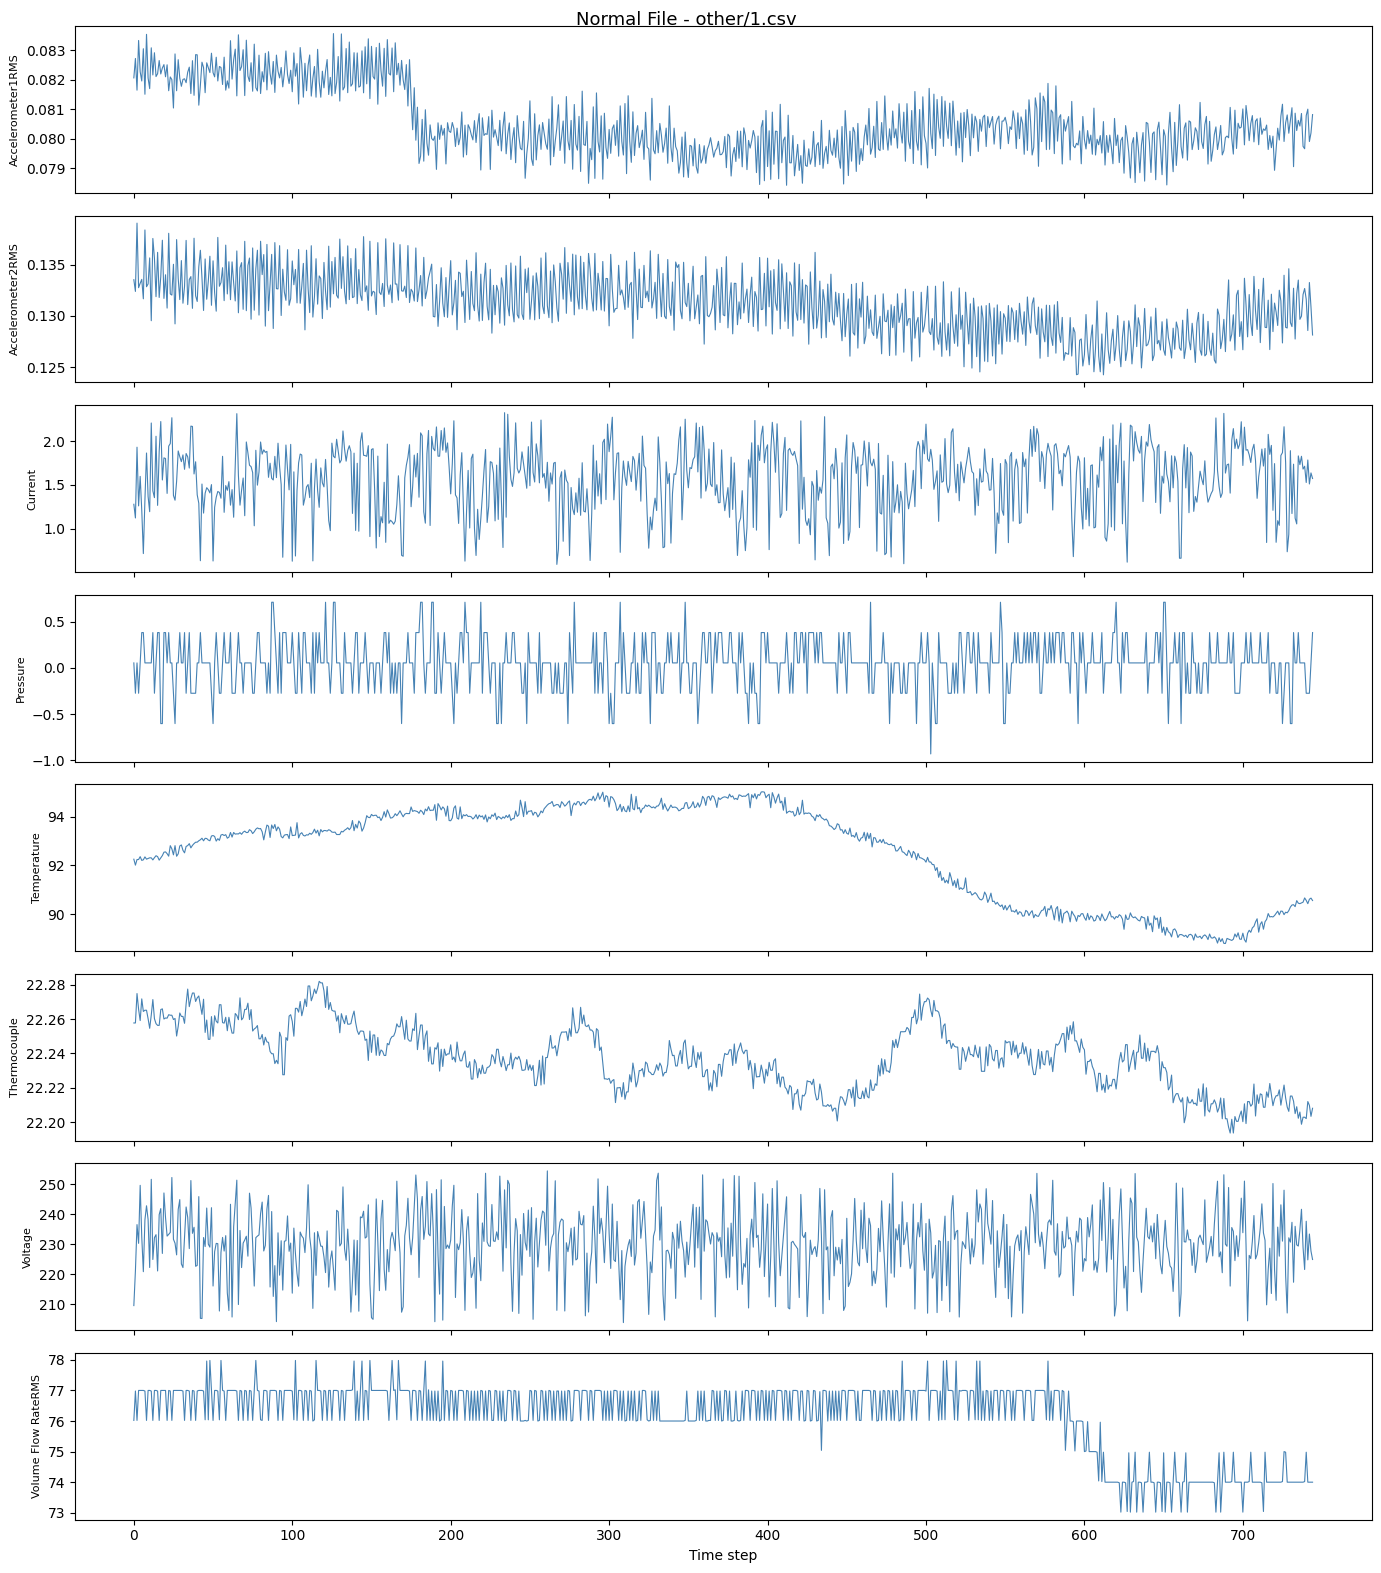

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(14, 16), sharex=True)
for i, col in enumerate(FEATURE_COLS):
    axes[i].plot(df_normal[col].values, color="steelblue", lw=0.8)
    axes[i].set_ylabel(col, fontsize=8)
axes[-1].set_xlabel("Time step")
fig.suptitle("Normal File - other/1.csv", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print("=== ANOMALY FILE ===")
print(df_anomaly[FEATURE_COLS].describe().round(3))

=== ANOMALY FILE ===
       Accelerometer1RMS  Accelerometer2RMS   Current  Pressure  Temperature  \
count           1145.000           1145.000  1145.000  1145.000     1145.000   
mean               0.027              0.040     0.979     0.074       73.714   
std                0.000              0.001     0.277     0.250        1.333   
min                0.026              0.038     0.375    -0.929       71.000   
25%                0.027              0.039     0.736     0.055       72.789   
50%                0.027              0.040     0.997     0.055       73.909   
75%                0.027              0.041     1.207     0.055       74.271   
max                0.028              0.053     1.596     1.038       76.280   

       Thermocouple   Voltage  Volume Flow RateRMS  
count      1145.000  1145.000             1145.000  
mean         25.740   231.413               31.567  
std           0.063    10.764                0.760  
min          25.611   203.738               30

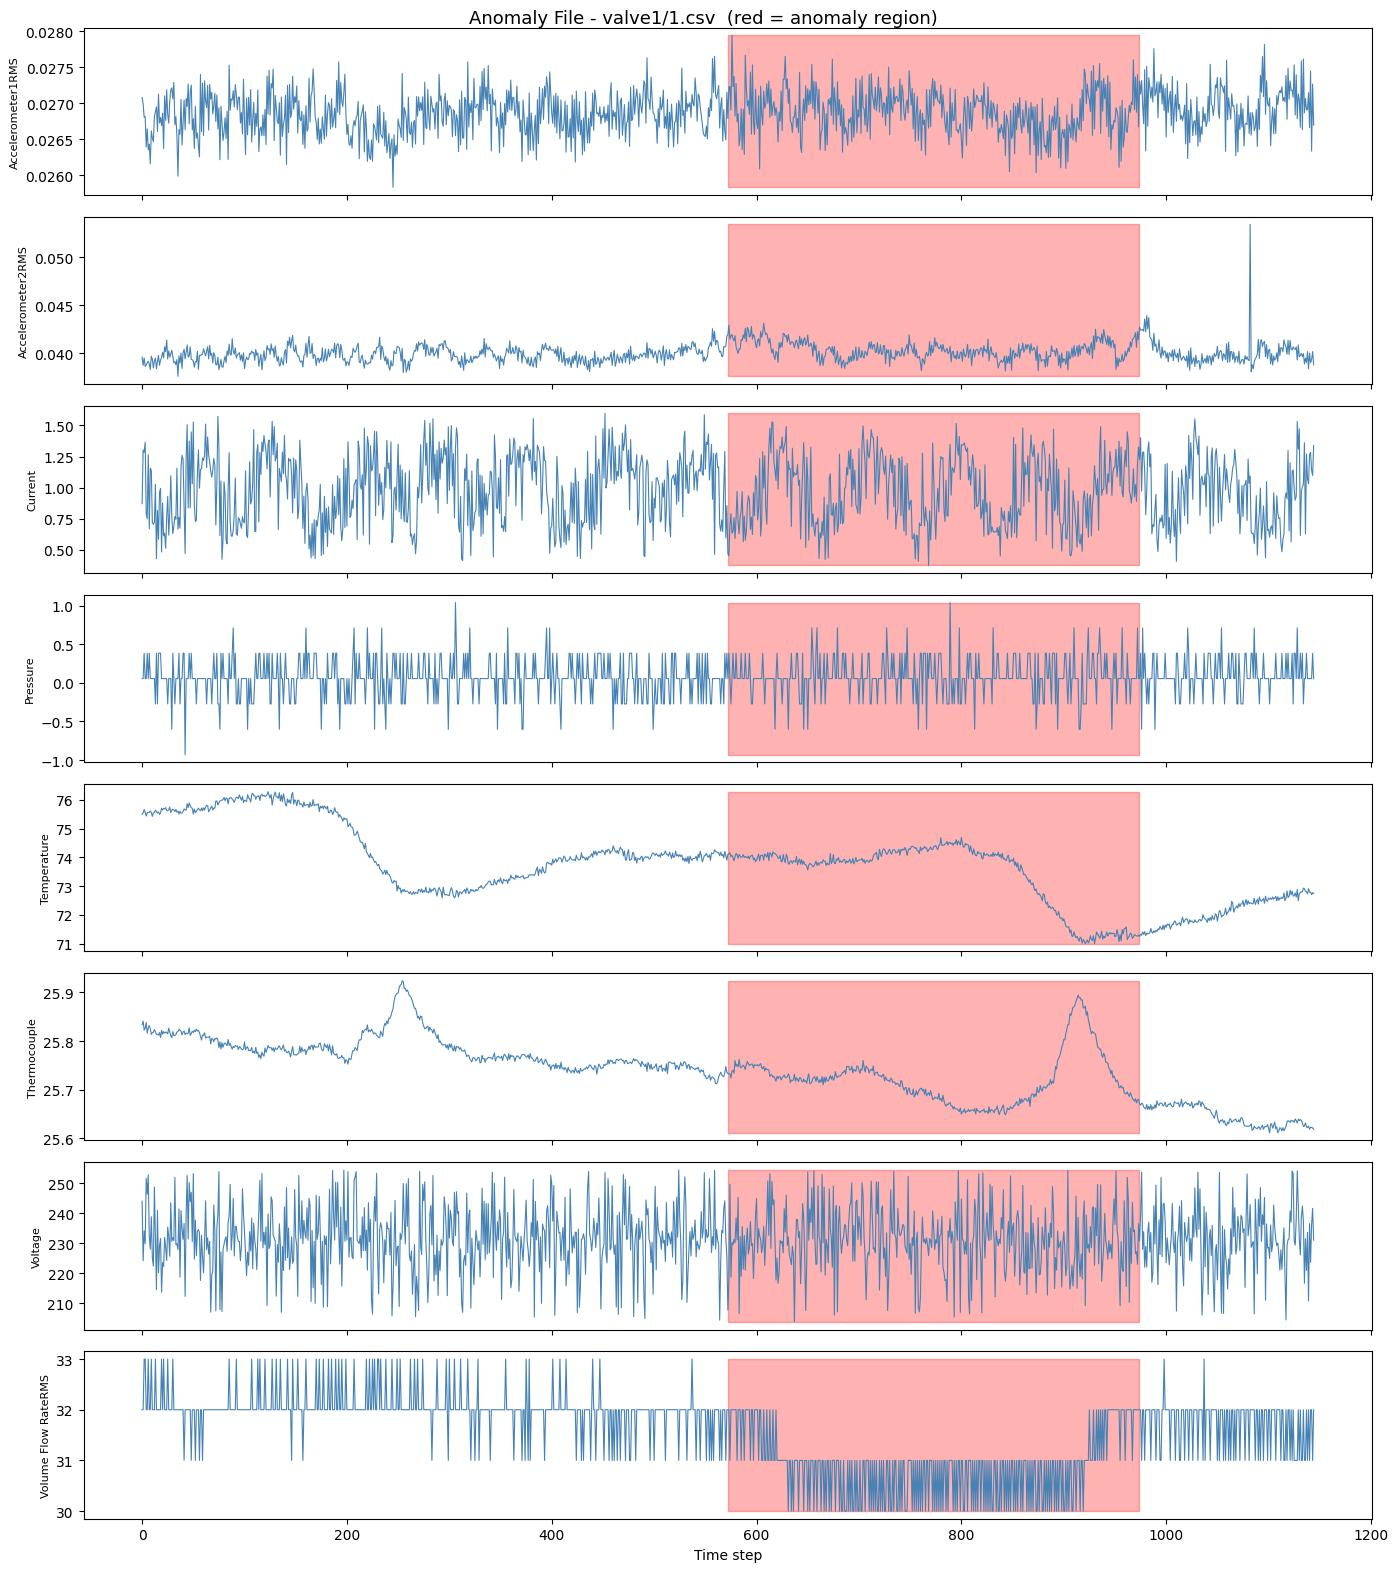

In [ ]:
fig, axes = plt.subplots(8, 1, figsize=(14, 16), sharex=True)
for i, col in enumerate(FEATURE_COLS):
    axes[i].plot(df_anomaly[col].values, color="steelblue", lw=0.8)
    axes[i].fill_between(range(len(df_anomaly)),
                         df_anomaly[col].min(), df_anomaly[col].max(),
                         where=df_anomaly["anomaly"].values == 1.0,
                         color="red", alpha=0.3)
    axes[i].set_ylabel(col, fontsize=8)
axes[-1].set_xlabel("Time step")
fig.suptitle("Anomaly File - valve1/1.csv  (red = anomaly region)", fontsize=13)
plt.tight_layout()
plt.show()

# **Conclusions**

What the statistics tell us
Accelerometers:

Normal mean: 0.081 and 0.131
Anomaly mean: 0.027 and 0.040
The vibration dropped significantly
the valve change affected the pump mechanics

Current:

Normal mean: 1.569
Anomaly mean: 0.979
Motor is drawing less current
flow is being restricted

Volume Flow RateRMS:

Normal mean: 76.157
Anomaly mean: 31.567
This is the most dramatic drop
flow cut by more than half — this is clearly the strongest signal of the valve anomaly

Temperature:

Normal mean: 92.568
Anomaly mean: 73.714
Fluid is cooler
Less flow means less heat transfer

Thermocouple, Voltage, Pressure:

Relatively stable across both files

Install Moment

In [ ]:
!pip install momentfm --no-deps
!pip install transformers einops huggingface-hub

  Using cached momentfm-0.1.4-py3-none-any.whl.metadata (16 kB)


In [ ]:
from momentfm import MOMENTPipeline

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "reconstruction"},
)
model.init()
print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

Model loaded successfully!


MOMENT has one requirement — it expects input in fixed windows of 512 time steps. Our normal data has 745 rows so we need to slice it into windows.

Cell — Prepare normal data windows:

In [ ]:
import numpy as np
import torch

X_normal = df_normal[df_normal["anomaly"] == 0.0][FEATURE_COLS].values.astype(np.float32)
X_anomaly = df_anomaly[FEATURE_COLS].values.astype(np.float32)

print("Normal clean shape:", X_normal.shape)
print("Anomaly shape:", X_anomaly.shape)

Normal clean shape: (557, 8)
Anomaly shape: (1145, 8)


In [ ]:
normal_mu = X_normal.mean(axis=0)
normal_std = X_normal.std(axis=0) + 1e-8

X_normal_scaled = (X_normal - normal_mu) / normal_std
X_anomaly_scaled = (X_anomaly - normal_mu) / normal_std

print("Normal scaled shape:", X_normal_scaled.shape)
print("Anomaly scaled shape:", X_anomaly_scaled.shape)

Normal scaled shape: (557, 8)
Anomaly scaled shape: (1145, 8)


Now we need to normalize each window before feeding to MOMENT, we use statistics

In [ ]:
windows_normal_s = create_windows(X_normal_scaled, seq_len=64, step=10)
windows_anomaly_s = create_windows(X_anomaly_scaled, seq_len=64, step=10)

print("Normal windows:", windows_normal_s.shape)
print("Anomaly windows:", windows_anomaly_s.shape)

Normal windows: (50, 64, 8)
Anomaly windows: (109, 64, 8)


Run MOMENT on normal data:

In [ ]:
X_norm_tensor = torch.tensor(windows_normal_s).permute(0, 2, 1).float()
mask_norm = torch.ones(X_norm_tensor.shape[0], X_norm_tensor.shape[2])

with torch.no_grad():
    out_norm = model(x_enc=X_norm_tensor, input_mask=mask_norm)

recon_norm = out_norm.reconstruction.numpy().transpose(0, 2, 1)
errors_norm = np.abs(windows_normal_s - recon_norm).mean(axis=2).flatten()

mu, sigma = norm.fit(errors_norm)
threshold = mu + 3 * sigma

print(f"μ = {mu:.4f}  σ = {sigma:.4f}  threshold = {threshold:.4f}")

μ = 0.6135  σ = 0.1817  threshold = 1.1586


Cell — Fit Gaussian  and get threshold:


In [ ]:
from scipy.stats import norm

mu, sigma = norm.fit(errors_normal)
threshold = mu + 3 * sigma

print(f"μ = {mu:.4f}")
print(f"σ = {sigma:.4f}")
print(f"Threshold (μ + 3σ) = {threshold:.4f}")

μ = 0.6084
σ = 0.1819
Threshold (μ + 3σ) = 1.1542


 Now let's visualize it to confirm it looks like a Gaussian before we use it as our threshold.

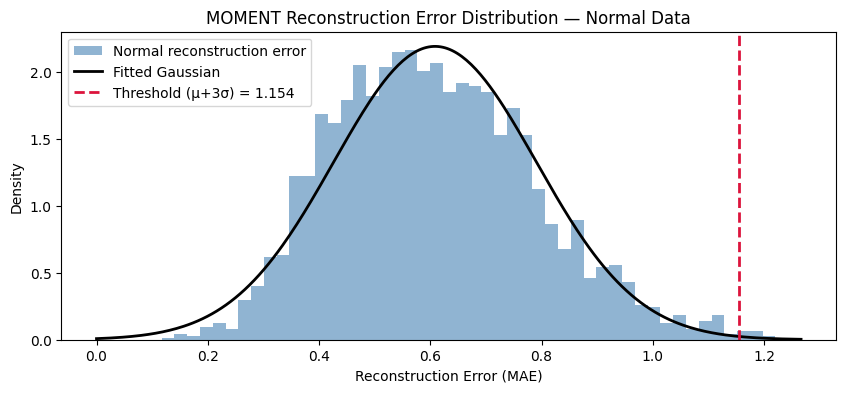

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(errors_normal, bins=50, density=True, color="steelblue", alpha=0.6, label="Normal reconstruction error")
x = np.linspace(0, errors_normal.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), "k-", lw=2, label="Fitted Gaussian")
plt.axvline(threshold, color="crimson", lw=2, ls="--", label=f"Threshold (μ+3σ) = {threshold:.3f}")
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Density")
plt.title("MOMENT Reconstruction Error Distribution — Normal Data")
plt.legend()
plt.show()

What this plot tells us

The histogram shows the reconstruction error distribution from all 2,816 normal timesteps

The distribution is smooth and bell-shaped — MOMENT reconstructs normal data consistently


μ = 0.608 — average reconstruction error on normal data


σ = 0.182 — small spread, meaning MOMENT is confident on normal data


Threshold = 1.154 — anything above this is flagged as anomalous

# New Section
# Prepare anomaly file windows:


 Run MOMENT on anomaly data

In [ ]:
X_anom_tensor = torch.tensor(windows_anomaly_s).permute(0, 2, 1).float()
mask_anom = torch.ones(X_anom_tensor.shape[0], X_anom_tensor.shape[2])

with torch.no_grad():
    out_anom = model(x_enc=X_anom_tensor, input_mask=mask_anom)

recon_anom = out_anom.reconstruction.numpy().transpose(0, 2, 1)
errors_anom = np.abs(windows_anomaly_s - recon_anom).mean(axis=2)

print("Anomaly errors shape:", errors_anom.shape)
print("Max error:", errors_anom.max().round(4))

Anomaly errors shape: (109, 64)
Max error: 1.4346


 Calculate anomaly reconstruction errors:

In [ ]:
T = len(X_anomaly)
err_sum = np.zeros(T)
err_count = np.zeros(T)

for i, start in enumerate(range(0, T - 128 + 1, 20)):
    err_sum[start : start + 128] += errors_anomaly[i]
    err_count[start : start + 128] += 1

err_count[err_count == 0] = 1
timestep_errors = err_sum / err_count

print("Max error:", timestep_errors.max().round(4))
print("Min error:", timestep_errors.min().round(4))
print("Timesteps above threshold:", (timestep_errors > threshold).sum())

Max error: 1.1963
Min error: 0.0
Timesteps above threshold: 1


Notice the mean error on the anomaly file 0.6535 is actually slightly lower than the normal file 0.7207. This tells us the windowed average is smoothing things out — the anomaly signal is getting diluted across the whole window.

Cell — Map errors back to original timesteps:


In [ ]:
# create an array to hold errors per original timestep
T = len(X_anomaly)
err_sum = np.zeros(T)
err_count = np.zeros(T)

step = 20
seq_len = 128

for i, start in enumerate(range(0, T - seq_len + 1, step)):
    err_sum[start : start + seq_len] += errors_anomaly_per_timestep[i]
    err_count[start : start + seq_len] += 1

# average overlapping windows
err_count[err_count == 0] = 1
timestep_errors = err_sum / err_count

print("Timestep errors shape:", timestep_errors.shape)
print("Max error:", timestep_errors.max().round(4))
print("Min error:", timestep_errors.min().round(4))

Timestep errors shape: (1145,)
Max error: 1.4759
Min error: 0.0


In [ ]:
T = len(X_anomaly)
err_sum_ch = np.zeros((T, 8))
err_count = np.zeros(T)

for i, start in enumerate(range(0, T - 64 + 1, 10)):
    err_sum_ch[start : start + 64] += np.abs(windows_anomaly_s[i] - recon_anom[i])
    err_count[start : start + 64] += 1

err_count[err_count == 0] = 1
timestep_errors_ch = err_sum_ch / err_count[:, None]

print("Per channel mean errors:")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {col}: {timestep_errors_ch[:, i].mean():.4f}  max: {timestep_errors_ch[:, i].max():.4f}")

Per channel mean errors:
  Accelerometer1RMS: 0.1910  max: 0.7037
  Accelerometer2RMS: 0.2098  max: 4.8328
  Current: 0.5409  max: 1.6579
  Pressure: 0.6653  max: 3.5307
  Temperature: 0.0939  max: 0.3017
  Thermocouple: 0.4846  max: 2.8919
  Voltage: 0.7459  max: 2.5692
  Volume Flow RateRMS: 0.6660  max: 2.3961


In [ ]:
T = len(X_anomaly)
err_sum = np.zeros(T)
err_count = np.zeros(T)

for i, start in enumerate(range(0, T - 64 + 1, 10)):
    # take max across channels instead of mean
    window_err = np.abs(windows_anomaly_s[i] - recon_anom[i]).max(axis=1)
    err_sum[start : start + 64] += window_err
    err_count[start : start + 64] += 1

err_count[err_count == 0] = 1
timestep_errors = err_sum / err_count

print("Max error:", timestep_errors.max().round(4))
print("Timesteps above threshold:", (timestep_errors > threshold).sum())

Max error: 4.8328
Timesteps above threshold: 684


The max error is 1.4656 which is above our threshold of 1.336 — that means MOMENT is already detecting something unusual. Now let's visualize it.

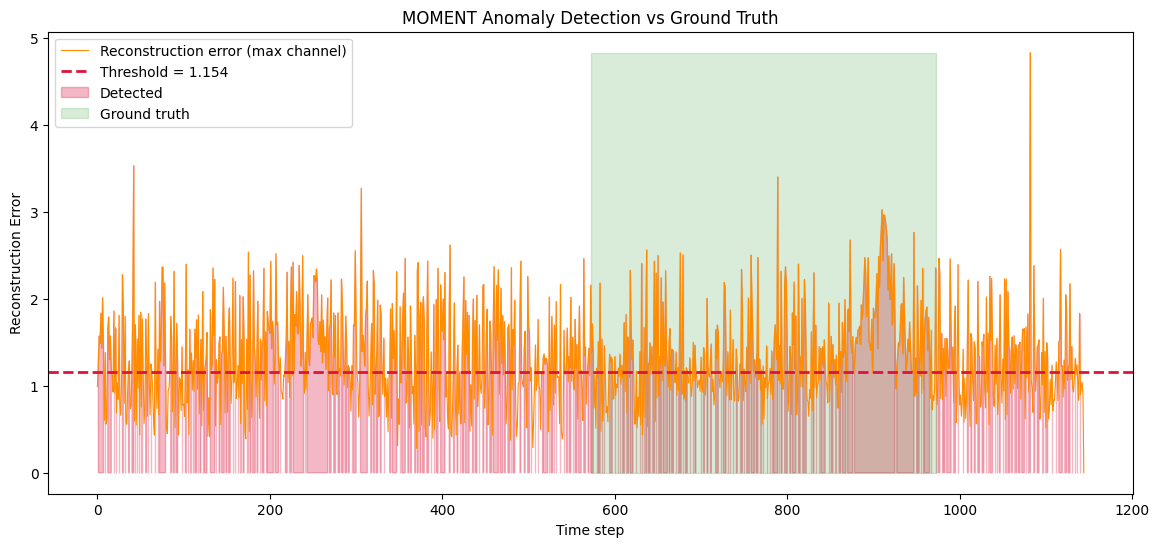

In [ ]:
y_true = df_anomaly["anomaly"].values

plt.figure(figsize=(14, 6))

# error signal
plt.plot(timestep_errors, color="darkorange", lw=0.8, label="Reconstruction error (max channel)")
plt.axhline(threshold, color="crimson", lw=2, ls="--", label=f"Threshold = {threshold:.3f}")

# shade detected anomalies
plt.fill_between(range(T), 0, timestep_errors,
                 where=timestep_errors > threshold,
                 color="crimson", alpha=0.3, label="Detected")

# shade ground truth
plt.fill_between(range(T), 0, timestep_errors.max(),
                 where=y_true == 1.0,
                 color="green", alpha=0.15, label="Ground truth")

plt.xlabel("Time step")
plt.ylabel("Reconstruction Error")
plt.title("MOMENT Anomaly Detection vs Ground Truth")
plt.legend()
plt.show()

Green region (step 600-950) = true anomaly ground truth
Pink/red shading = what MOMENT detected
The error signal is noisy and spiky throughout the entire file — MOMENT is firing everywhere, not just in the anomaly region
There are many false positives before step 600 — detected anomalies in the normal region
Inside the green region the error is actually lower and more stable — the anomaly caused the sensors to settle into a new steady state which MOMENT reconstructs wel

The core problem
The threshold of 1.154 is too low — it catches too much noise. Let's raise it to μ + 5σ to reduce false positives.

In [ ]:
threshold_new = mu + 5 * sigma

print(f"New threshold (μ+5σ) = {threshold_new:.4f}")
print("Timesteps above threshold:", (timestep_errors > threshold_new).sum())

New threshold (μ+5σ) = 1.5181
Timesteps above threshold: 381


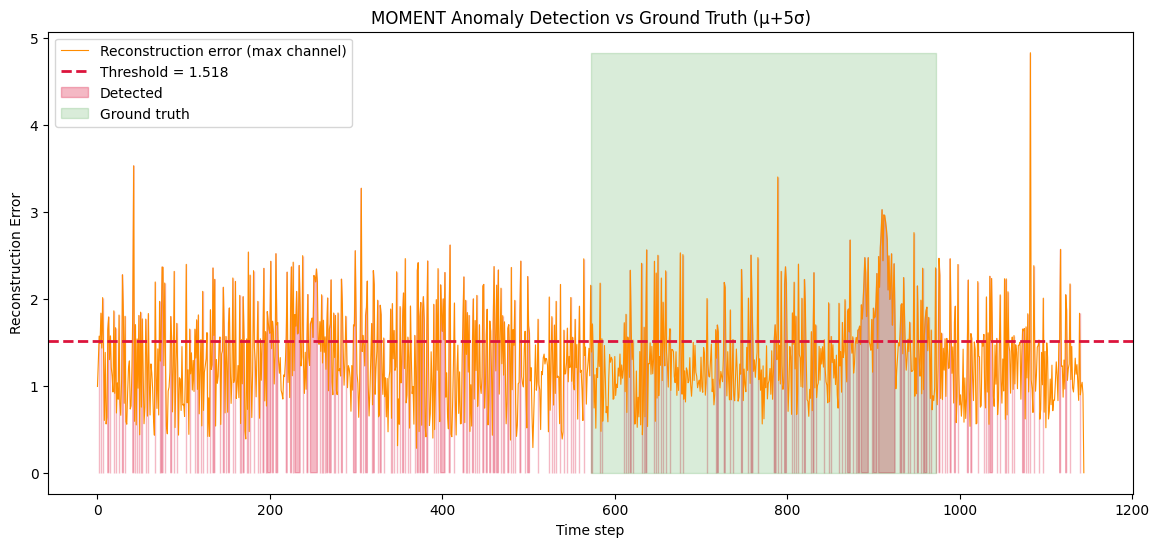

In [ ]:
y_true = df_anomaly["anomaly"].values

plt.figure(figsize=(14, 6))
plt.plot(timestep_errors, color="darkorange", lw=0.8, label="Reconstruction error (max channel)")
plt.axhline(threshold_new, color="crimson", lw=2, ls="--", label=f"Threshold = {threshold_new:.3f}")
plt.fill_between(range(T), 0, timestep_errors,
                 where=timestep_errors > threshold_new,
                 color="crimson", alpha=0.3, label="Detected")
plt.fill_between(range(T), 0, timestep_errors.max(),
                 where=y_true == 1.0,
                 color="green", alpha=0.15, label="Ground truth")
plt.xlabel("Time step")
plt.ylabel("Reconstruction Error")
plt.title("MOMENT Anomaly Detection vs Ground Truth (μ+5σ)")
plt.legend()
plt.show()

 Compute predictions and range-based metrics:


In [ ]:
y_pred = (timestep_errors > threshold_new).astype(int)
y_true = df_anomaly["anomaly"].values.astype(int)

print("Predicted anomalies:", y_pred.sum())
print("True anomalies:", y_true.sum())
print("True positives:", ((y_pred == 1) & (y_true == 1)).sum())
print("False positives:", ((y_pred == 1) & (y_true == 0)).sum())
print("False negatives:", ((y_pred == 0) & (y_true == 1)).sum())

Predicted anomalies: 381
True anomalies: 402
True positives: 126
False positives: 255
False negatives: 276


Range-based metrics:


In [ ]:
def find_intervals(arr):
    intervals, in_run, s = [], False, 0
    for i, v in enumerate(arr):
        if v == 1 and not in_run:
            s, in_run = i, True
        elif v == 0 and in_run:
            intervals.append((s, i - 1))
            in_run = False
    if in_run:
        intervals.append((s, len(arr) - 1))
    return intervals

def range_f1(y_true, y_pred):
    true_intervals = find_intervals(y_true)
    pred_intervals = find_intervals(y_pred)

    # range recall
    recalls = []
    for ts, te in true_intervals:
        overlap = sum(max(0, min(pe, te) - max(ps, ts) + 1)
                      for ps, pe in pred_intervals)
        recalls.append(overlap / (te - ts + 1))
    range_recall = np.mean(recalls) if recalls else 0.0

    # range precision
    precisions = []
    for ps, pe in pred_intervals:
        overlap = sum(max(0, min(pe, te) - max(ps, ts) + 1)
                      for ts, te in true_intervals)
        precisions.append(overlap / (pe - ps + 1))
    range_precision = np.mean(precisions) if precisions else 0.0

    # range f1
    if range_precision + range_recall == 0:
        rf1 = 0.0
    else:
        rf1 = 2 * range_precision * range_recall / (range_precision + range_recall)

    return range_precision, range_recall, rf1

rp, rr, rf1 = range_f1(y_true, y_pred)
print(f"Range Precision : {rp:.4f}")
print(f"Range Recall    : {rr:.4f}")
print(f"Range F1        : {rf1:.4f}")

Range Precision : 0.2917
Range Recall    : 0.3134
Range F1        : 0.3022


Cell — Range-based PR curve by sweeping thresholds:


In [ ]:
thresholds = np.percentile(timestep_errors, np.linspace(50, 99, 50))

rp_list, rr_list, rf1_list = [], [], []

for thr in thresholds:
    yp = (timestep_errors > thr).astype(int)
    rp, rr, rf1 = range_f1(y_true, yp)
    rp_list.append(rp)
    rr_list.append(rr)
    rf1_list.append(rf1)

best_idx = np.argmax(rf1_list)
print(f"Best Range-F1: {rf1_list[best_idx]:.4f}")
print(f"Best Range-P:  {rp_list[best_idx]:.4f}")
print(f"Best Range-R:  {rr_list[best_idx]:.4f}")
print(f"Best threshold: {thresholds[best_idx]:.4f}")

Best Range-F1: 0.4009
Best Range-P:  0.3262
Best Range-R:  0.5199
Best threshold: 1.2882


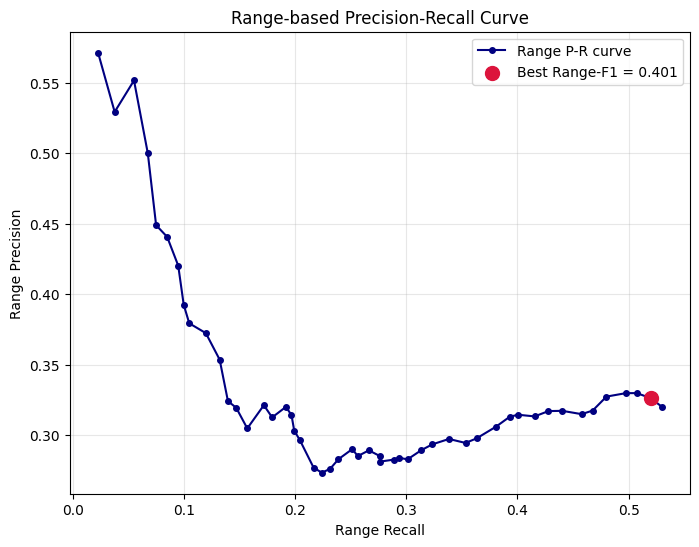

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(rr_list, rp_list, "o-", color="navy", lw=1.5, ms=4, label="Range P-R curve")
plt.scatter(rr_list[best_idx], rp_list[best_idx], color="crimson", s=100, zorder=5,
            label=f"Best Range-F1 = {rf1_list[best_idx]:.3f}")
plt.xlabel("Range Recall")
plt.ylabel("Range Precision")
plt.title("Range-based Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

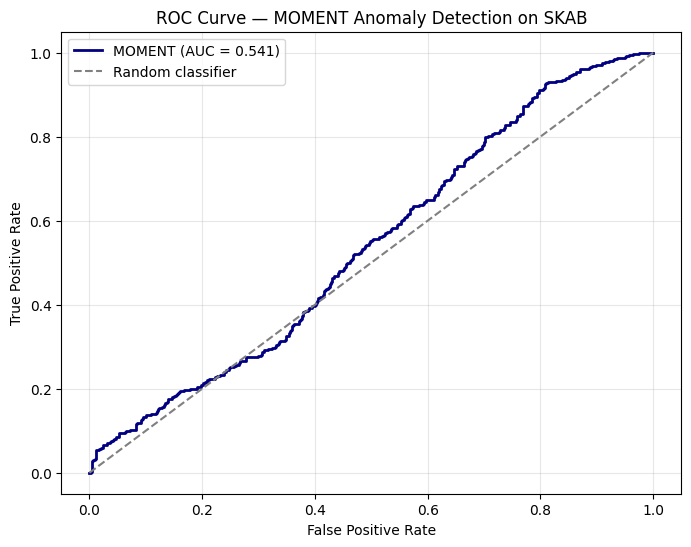

AUC: 0.5406


In [ ]:
from sklearn.metrics import roc_curve, auc

# standard ROC curve using raw error scores
fpr, tpr, _ = roc_curve(y_true, timestep_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="navy", lw=2, label=f"MOMENT (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, ls="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — MOMENT Anomaly Detection on SKAB")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {roc_auc:.4f}")

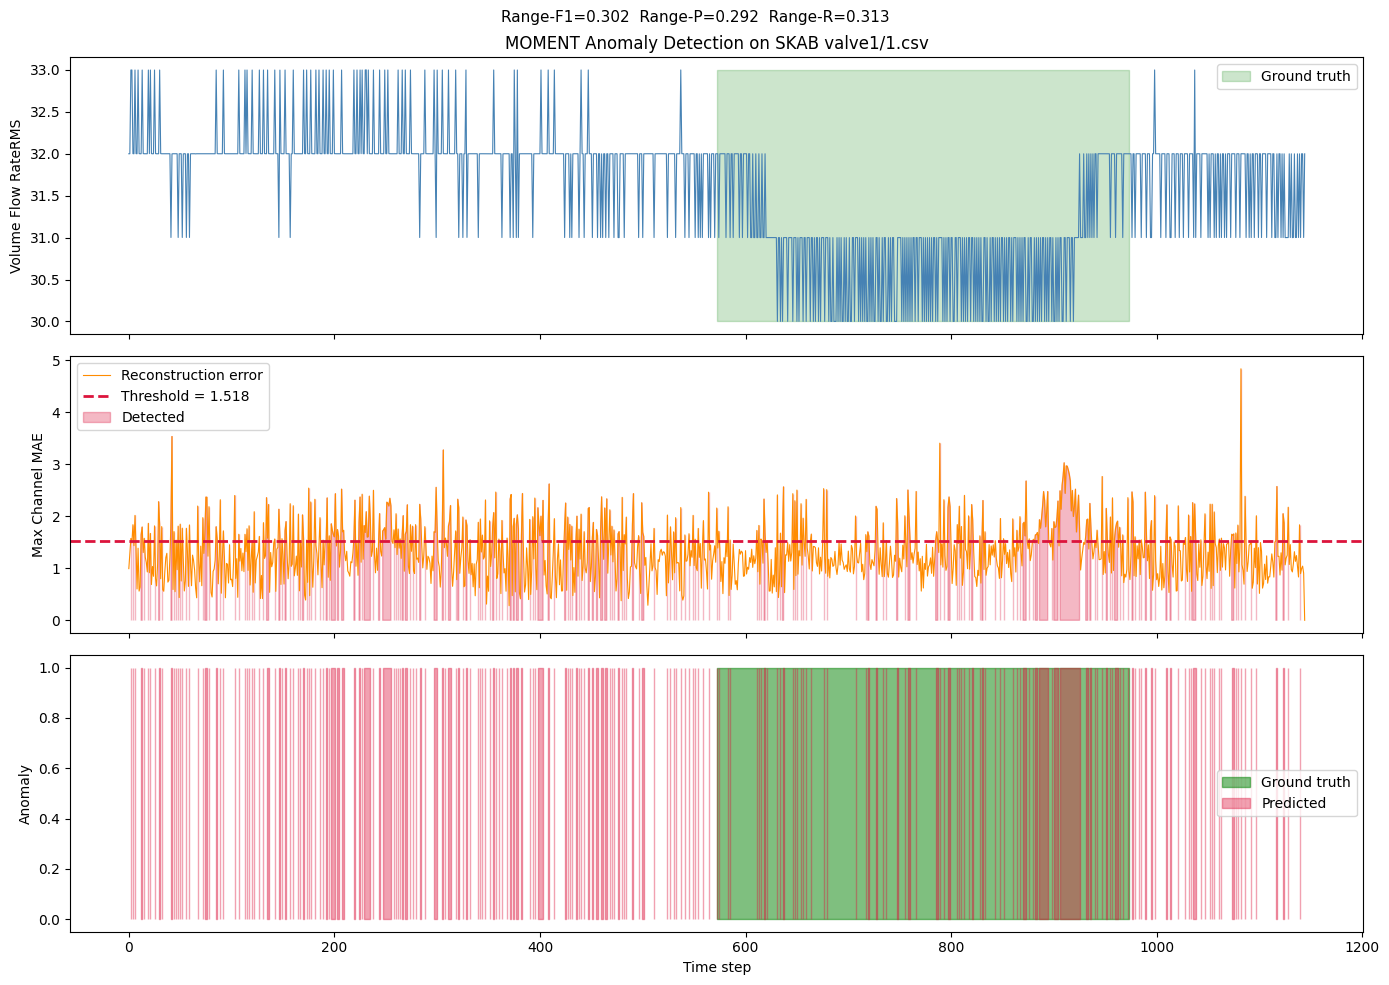

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — sensor signal
axes[0].plot(df_anomaly["Volume Flow RateRMS"].values, color="steelblue", lw=0.8)
axes[0].fill_between(range(T), df_anomaly["Volume Flow RateRMS"].min(),
                     df_anomaly["Volume Flow RateRMS"].max(),
                     where=y_true == 1, color="green", alpha=0.2, label="Ground truth")
axes[0].set_ylabel("Volume Flow RateRMS")
axes[0].set_title("MOMENT Anomaly Detection on SKAB valve1/1.csv")
axes[0].legend()

# Panel 2 — reconstruction error
axes[1].plot(timestep_errors, color="darkorange", lw=0.8, label="Reconstruction error")
axes[1].axhline(threshold_new, color="crimson", lw=2, ls="--", label=f"Threshold = {threshold_new:.3f}")
axes[1].fill_between(range(T), 0, timestep_errors,
                     where=y_pred == 1, color="crimson", alpha=0.3, label="Detected")
axes[1].set_ylabel("Max Channel MAE")
axes[1].legend()

# Panel 3 — ground truth vs predicted
axes[2].fill_between(range(T), 0, 1, where=y_true == 1,
                     color="green", alpha=0.5, label="Ground truth")
axes[2].fill_between(range(T), 0, 1, where=y_pred == 1,
                     color="crimson", alpha=0.4, label="Predicted")
axes[2].set_ylabel("Anomaly")
axes[2].set_xlabel("Time step")
axes[2].legend()

fig.suptitle(f"Range-F1={rf1:.3f}  Range-P={rp:.3f}  Range-R={rr:.3f}", fontsize=11)
plt.tight_layout()
plt.show()

FAR and MAR:

In [ ]:
# False Alarm Rate — false positives out of all true negatives
FAR = ((y_pred == 1) & (y_true == 0)).sum() / (y_true == 0).sum()

# Missing Alarm Rate — false negatives out of all true anomalies
MAR = ((y_pred == 0) & (y_true == 1)).sum() / (y_true == 1).sum()

# Point-based F1
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)

print(f"F1  : {f1:.4f}")
print(f"FAR : {FAR*100:.2f}%")
print(f"MAR : {MAR*100:.2f}%")

F1  : 0.3218
FAR : 34.32%
MAR : 68.66%


Our MOMENT zero-shot scores above Isolation Forest and above the Null detector
FAR of 34.32% — we have too many false alarms, firing on normal noise
MAR of 68.66% — we are missing most of the anomaly region
This is expected for a zero-shot model with only 557 normal training rows